In [93]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


In [ ]:
# IOT FRIDGE DATA

In [94]:

# Load the dataset
df = pd.read_csv("Train_Test_IoT_Fridge.csv")


In [95]:

# Data Exploration and Preprocessing
print("Initial DataFrame:")
print(df.head())



Initial DataFrame:
        date        time  fridge_temperature temp_condition  label  type
0  25-Apr-19   19:19:40                 9.00           high      1  ddos
1  25-Apr-19   19:19:40                 9.25           high      1  ddos
2  25-Apr-19   19:19:45                12.65           high      1  ddos
3  25-Apr-19   19:19:45                 4.65            low      1  ddos
4  25-Apr-19   19:19:55                12.65           high      1  ddos


In [96]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39944 entries, 0 to 39943
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                39944 non-null  object 
 1   time                39944 non-null  object 
 2   fridge_temperature  39944 non-null  float64
 3   temp_condition      39944 non-null  object 
 4   label               39944 non-null  int64  
 5   type                39944 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.8+ MB


In [97]:
df['temp_condition'].unique()

array(['high', 'low', 'high ', 'low ', 'low  ', 'high  '], dtype=object)

In [98]:
df['temp_condition']=df['temp_condition'].map({'high':'high', 'low':'low', 'high ':'high', 'low ':'low', 'low  ':'low', 'high  ':'high'})

In [99]:
df['temp_condition']=df['temp_condition'].map({'high':1,'low':0})

In [100]:
df['temp_condition'].value_counts()

,count
temp_condition,
1,22386
0,17558


In [101]:
df['type'].unique()

array(['ddos', 'backdoor', 'injection', 'normal', 'password',
       'ransomware', 'xss'], dtype=object)

In [102]:
df['type'].value_counts()

,count
type,
normal,15000
backdoor,5000
ddos,5000
injection,5000
password,5000
ransomware,2902
xss,2042


In [103]:
df

,date,time,fridge_temperature,temp_condition,label,type
0,25-Apr-19,19:19:40,9.00,1,1,ddos
1,25-Apr-19,19:19:40,9.25,1,1,ddos
2,25-Apr-19,19:19:45,12.65,1,1,ddos
3,25-Apr-19,19:19:45,4.65,0,1,ddos
4,25-Apr-19,19:19:55,12.65,1,1,ddos
...,...,...,...,...,...,...
39939,27-Apr-19,05:13:35,13.25,1,1,xss
39940,27-Apr-19,05:13:36,4.35,0,1,xss
39941,27-Apr-19,05:13:36,1.00,0,1,xss
39942,27-Apr-19,05:13:36,10.25,1,1,xss


In [104]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Strip spaces from date and time columns
df['date'] = df['date'].astype(str).str.strip()
df['time'] = df['time'].astype(str).str.strip()

# Try parsing with mixed formats automatically
df['datetime'] = pd.to_datetime(
    df['date'] + ' ' + df['time'],
    format='mixed',  # lets pandas handle inconsistent formats
    errors='coerce'  # replaces invalid formats with NaT
)

# Drop rows where datetime couldn't be parsed (if any)
df = df.dropna(subset=['datetime'])

# Drop old columns
df = df.drop(['date', 'time'], axis=1)

# Encode categorical features
categorical_cols = ['type']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    joblib.dump(le, f'{col}_encoder.pkl')



#

print("\n✅ DataFrame after preprocessing:")
display(df.head())



✅ DataFrame after preprocessing:


,fridge_temperature,temp_condition,label,type,datetime
0,9.00,1,1,1,2019-04-25 19:19:40
1,9.25,1,1,1,2019-04-25 19:19:40
2,12.65,1,1,1,2019-04-25 19:19:45
3,4.65,0,1,1,2019-04-25 19:19:45
4,12.65,1,1,1,2019-04-25 19:19:55


In [105]:
df.isna().sum()

,0
fridge_temperature,0
temp_condition,0
label,0
type,0
datetime,0


In [106]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, utils
from collections import Counter


In [107]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday

In [108]:
df = df.drop(columns=['datetime'])

In [109]:


# Separate features (X) and target (y)
X = df.drop(columns=["label", "type"])  # Removed 'type' as per your code
y = df["type"]


In [110]:
X

,fridge_temperature,temp_condition,hour,day,month,weekday
0,9.00,1,19,25,4,3
1,9.25,1,19,25,4,3
2,12.65,1,19,25,4,3
3,4.65,0,19,25,4,3
4,12.65,1,19,25,4,3
...,...,...,...,...,...,...
39939,13.25,1,5,27,4,5
39940,4.35,0,5,27,4,5
39941,1.00,0,5,27,4,5
39942,10.25,1,5,27,4,5


In [111]:
X.dtypes

,0
fridge_temperature,float64
temp_condition,int64
hour,int32
day,int32
month,int32
weekday,int32


In [112]:
y.dtypes

dtype('int64')

In [113]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [114]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [117]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

num_classes = len(le.classes_)
input_dim = X_train_scaled.shape[1]

# Handle imbalance
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights = dict(enumerate(class_weights))

# Build model (simple deep dense)
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
mc = callbacks.ModelCheckpoint('network_attack_model.h5', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[es, mc],
    verbose=2
)

model.save('final_network_model.h5')


Epoch 1/50


110/110 - 6s - 57ms/step - accuracy: 0.7515 - loss: 0.8869 - val_accuracy: 0.2351 - val_loss: 1.6496
Epoch 2/50


110/110 - 1s - 9ms/step - accuracy: 0.9559 - loss: 0.2496 - val_accuracy: 0.6771 - val_loss: 1.1880
Epoch 3/50


110/110 - 1s - 7ms/step - accuracy: 0.9874 - loss: 0.0906 - val_accuracy: 0.7532 - val_loss: 0.6945
Epoch 4/50


110/110 - 1s - 6ms/step - accuracy: 0.9953 - loss: 0.0421 - val_accuracy: 0.9281 - val_loss: 0.2317
Epoch 5/50


...

110/110 - 1s - 5ms/step - accuracy: 0.9996 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 2.6555e-04
Epoch 12/50
110/110 - 1s - 5ms/step - accuracy: 0.9994 - loss: 0.0054 - val_accuracy: 0.9997 - val_loss: 9.6074e-04
Epoch 13/50
110/110 - 1s - 6ms/step - accuracy: 0.9996 - loss: 0.0049 - val_accuracy: 0.9997 - val_loss: 0.0013
Epoch 14/50


110/110 - 1s - 5ms/step - accuracy: 0.9998 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 1.2460e-04
Epoch 15/50
110/110 - 1s - 5ms/step - accuracy: 0.9997 - loss: 0.0034 - val_accuracy: 0.9997 - val_loss: 5.7802e-04
Epoch 16/50
110/110 - 1s - 5ms/step - accuracy: 0.9993 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 3.0405e-04
Epoch 17/50


110/110 - 1s - 6ms/step - accuracy: 0.9992 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 9.8596e-05
Epoch 18/50
110/110 - 1s - 5ms/step - accuracy: 0.9996 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 2.8764e-04
Epoch 19/50
110/110 - 1s - 6ms/step - accuracy: 0.9996 - loss: 0.0031 - val_accuracy: 0.9997 - val_loss: 3.7564e-04
Epoch 20/50
110/110 - 1s - 8ms/step - accuracy: 0.9997 - loss: 0.0022 - val_accuracy: 0.9997 - val_loss: 0.0012
Epoch 21/50


110/110 - 1s - 9ms/step - accuracy: 0.9997 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 8.6749e-05
Epoch 22/50
110/110 - 1s - 6ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accuracy: 0.9997 - val_loss: 8.2926e-04
Epoch 23/50
110/110 - 1s - 11ms/step - accuracy: 0.9997 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 1.2607e-04
Epoch 24/50
110/110 - 1s - 5ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 2.2192e-04
Epoch 25/50


110/110 - 1s - 5ms/step - accuracy: 0.9996 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 5.8408e-05
Epoch 26/50
110/110 - 1s - 6ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 1.1215e-04
Epoch 27/50
110/110 - 1s - 5ms/step - accuracy: 0.9996 - loss: 0.0025 - val_accuracy: 0.9997 - val_loss: 3.8744e-04
Epoch 28/50
110/110 - 1s - 6ms/step - accuracy: 0.9999 - loss: 0.0010 - val_accuracy: 0.9997 - val_loss: 2.9445e-04
Epoch 29/50
110/110 - 1s - 6ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 3.1553e-04
Epoch 30/50
110/110 - 1s - 6ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 2.2048e-04
Epoch 31/50
110/110 - 1s - 5ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 6.7056e-05


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


<Figure size 1000x800 with 0 Axes>

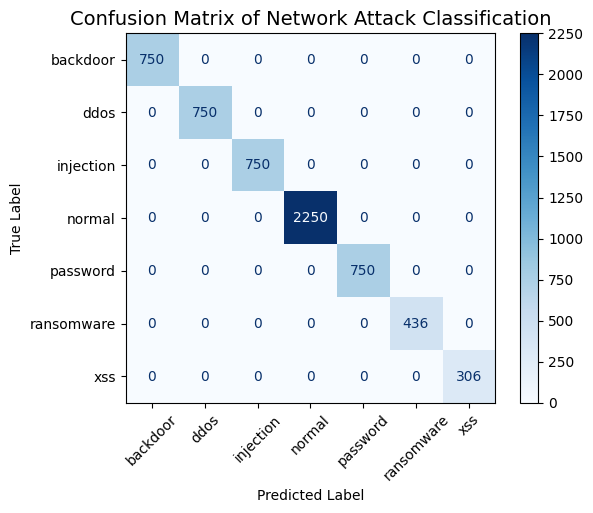


Classification Report:

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00       750
        ddos       1.00      1.00      1.00       750
   injection       1.00      1.00      1.00       750
      normal       1.00      1.00      1.00      2250
    password       1.00      1.00      1.00       750
  ransomware       1.00      1.00      1.00       436
         xss       1.00      1.00      1.00       306

    accuracy                           1.00      5992
   macro avg       1.00      1.00      1.00      5992
weighted avg       1.00      1.00      1.00      5992



In [121]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict on test set
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Plot as heatmap
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d', colorbar=True)
plt.title("Confusion Matrix of Network Attack Classification", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

# Optionally print detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


In [134]:
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

def predict_attack_type(new_data):
    """
    Predicts the network attack type for new data.

    Args:
        new_data (dict): A dictionary containing the new data with keys:
                         'fridge_temperature', 'temp_condition', 'hour',
                         'day', 'month', 'weekday'.

    Returns:
        str: The predicted network attack type.
    """
    # Load the scaler and model
    scaler = joblib.load('scaler.pkl')
    model = tf.keras.models.load_model('final_network_model.h5')
    le = joblib.load('type_encoder.pkl')


    # Create a DataFrame from the new data
    new_df = pd.DataFrame([new_data])

    # Preprocess the new data
    # Encode 'temp_condition' - assuming it's still 'high' or 'low' string
    new_df['temp_condition'] = new_df['temp_condition'].map({'high': 1, 'low': 0})



    # Select the features used for training (excluding 'label' and 'type')
    features = ['fridge_temperature', 'temp_condition', 'hour', 'day', 'month', 'weekday']
    new_data_scaled = new_df[features]
    new_data_scaled=scaler.transform(new_data_scaled)


    # Make prediction
    prediction_probs = model.predict(new_data_scaled)
    predicted_class_index = np.argmax(prediction_probs, axis=1)[0]

    # Decode the predicted class
    predicted_attack_type = le.inverse_transform([predicted_class_index])[0]

    return predicted_attack_type

# Example usage:
new_sample = {'fridge_temperature': 13.10, 'temp_condition': 'high', 'hour': 12, 'day': 31, 'month': 3, 'weekday': 6}
predicted_type = predict_attack_type(new_sample)
print(f"The predicted attack type is: {predicted_type}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
The predicted attack type is: normal


In [133]:
df[df['type']==3]

,fridge_temperature,temp_condition,label,type,hour,day,month,weekday
6847,13.10,1,0,3,12,31,3,6
6848,8.65,1,0,3,12,31,3,6
6849,2.00,0,0,3,12,31,3,6
6850,4.80,0,0,3,12,31,3,6
6851,10.70,1,0,3,12,31,3,6
...,...,...,...,...,...,...,...,...
29995,3.00,0,0,3,4,2,4,1
29996,5.40,0,0,3,4,2,4,1
29997,8.85,1,0,3,4,2,4,1
29998,3.00,0,0,3,4,2,4,1


In [129]:
df['type'].value_counts()

,count
type,
3,15000
0,5000
1,5000
2,5000
4,5000
5,2902
6,2042


In [126]:
# normal	15000
# backdoor	5000
# ddos	5000
# injection	5000
# password	5000
# ransomware	2902
# xss	2042


np.int64(0)